## Hypothesis: Momentum × extreme negative sentiment (conditional forward returns)

**Origin** — Follow-up to `03-hyp_neg_sent_risk.ipynb`: after controlling for prior-day **momentum**, does **extreme** negative headline sentiment modify the relationship between momentum and **next-day** returns (and the probability of a down day)?

**Question** — Is the slope of forward return on momentum **different** under extreme negative sentiment vs normal negative sentiment?

**Model (linear)**  
`forward_return_1d ~ momentum_1d + neg_extreme + (momentum_1d * neg_extreme)`

**Model (downside probability)**  
`P(forward_return_1d < 0)` via logistic regression with the same linear predictors (+ interaction).

**Assumptions**

- **Window**: `WINDOW_START`–`WINDOW_END` from `msa.utils.vars` (aligned with other hypothesis notebooks).
- **Universe**: MAG7; articles with `sentiment_label == "negative"`.
- **Extreme definition**: by default, **bottom 10%** of `sentiment_score` among *all* negative articles in the window (robustness: 20%, fixed quantiles).
- **Returns**: daily close-to-close panel; `forward_return_1d` is the **next** trading day’s return (`groupby("ticker")` shift on the daily panel), merged to article rows by `(price_date, ticker)`.
- **Momentum**: prior trading day’s daily return (`return_1d` lagged by 1 within ticker).

**Objectives**

1. Regression-based validation with **inference** (OLS + interaction interpretation).
2. **Logistic** framing for downside probability.
3. **Regime plots**: momentum vs forward return under normal vs extreme negative sentiment.
4. **Robustness** across extreme definitions (10% vs 20%, alternative cutoffs).
5. **Temporal stability** (early vs late window, by year).
6. If results are stable, treat **momentum as primary** and **sentiment as a conditional modifier** for downstream modeling.


## Data loading (minimal)

Load the joined GDELT + OHLCV file used across hypothesis notebooks.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

from msa.utils.paths import get_joined_dataset
from msa.utils.vars import MAG7_TICKERS, WINDOW_END, WINDOW_START

warnings.filterwarnings("ignore", category=FutureWarning)

INPUT_PATH = get_joined_dataset()
df = pd.read_csv(
    INPUT_PATH,
    parse_dates=["date", "article_date", "price_date"],
)

print(f"Loaded {len(df):,} rows from {INPUT_PATH.name}")
df.head()


Loaded 89,405 rows from gdelt_ohlcv_join.csv


,seendate,url,title,language,domain,socialimage,company,ticker,date,sentiment_score,sentiment_confidence,sentiment_label,article_date,price_date,next_open,next_high,next_low,next_close,next_adj_close,next_volume
0,2024-02-08 00:00:00+00:00,https://www.businesstimes.com.sg/companies-mar...,Arm soars after expansion into new markets buo...,English,businesstimes.com.sg,https://static1.businesstimes.com.sg/s3fs-publ...,Apple,AAPL,2024-02-08,0.815164,0.877368,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
1,2024-02-08 00:45:00+00:00,https://www.hucknalldispatch.co.uk/lifestyle/f...,Dutch Barn Orchard Vodka achieves nationwide l...,English,hucknalldispatch.co.uk,https://www.hucknalldispatch.co.uk/webimg/b25l...,Apple,AAPL,2024-02-08,0.927444,0.938555,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
2,2024-02-08 00:45:00+00:00,https://www.fool.com/earnings/call-transcripts...,PayPal ( PYPL ) Q4 2023 Earnings Call Transcript,English,fool.com,NaN,Apple,AAPL,2024-02-08,-0.010950,0.934771,neutral,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
3,2024-02-08 01:15:00+00:00,https://invezz.com/news/2024/02/07/disney-q1-e...,Disney Q1 earnings : dividend increased as DTC...,English,invezz.com,https://invezz.com/wp-content/uploads/2022/11/...,Apple,AAPL,2024-02-08,0.838071,0.908904,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
4,2024-02-08 01:15:00+00:00,https://www.nbcnewyork.com/news/business/money...,"Jim Cramer says recent moves in Apple , Chipot...",English,nbcnewyork.com,https://media.nbcnewyork.com/2023/11/107113454...,Apple,AAPL,2024-02-08,-0.320946,0.543592,neutral,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200


## Data filtering

Same window and MAG7 filter as notebook 03; keep **all** negative-sentiment rows for the conditional analysis (extreme vs non-extreme is defined *within* negatives).

In [2]:
print("=" * 70)
print("DATA FILTERING PIPELINE")
print("=" * 70)

print(f"\n1. Initial dataset: {len(df):,} rows")

df_filtered = df[
    (df["price_date"].dt.normalize() >= pd.Timestamp(WINDOW_START))
    & (df["price_date"].dt.normalize() <= pd.Timestamp(WINDOW_END))
].copy()
print(f"2. After date window ({WINDOW_START} to {WINDOW_END}): {len(df_filtered):,} rows")

df_mag7 = df_filtered[df_filtered["ticker"].isin(MAG7_TICKERS)].copy()
print(f"3. After MAG7 filter: {len(df_mag7):,} rows")

df_mag7_neg = df_mag7[df_mag7["sentiment_label"] == "negative"].copy()
print(f"4. Negative-sentiment rows: {len(df_mag7_neg):,}")

print("\n" + "=" * 70)


DATA FILTERING PIPELINE

1. Initial dataset: 89,405 rows
2. After date window (2024-02-23 to 2026-02-23): 88,851 rows
3. After MAG7 filter: 88,851 rows
4. Negative-sentiment rows: 11,145



## Calculations: daily returns, forward return, merge to articles

Build one row per `(price_date, ticker)` for `return_1d` and `forward_return_1d`, then merge onto **every** negative article (not only the bottom decile).

In [3]:
# Daily panel: close from first row per (price_date, ticker) in join
returns_daily = (
    df_mag7.groupby(["price_date", "ticker"], as_index=False).agg(close=("next_close", "first"))
)
returns_daily["price_date"] = pd.to_datetime(returns_daily["price_date"]).dt.normalize()
returns_daily = returns_daily.sort_values(["ticker", "price_date"]).reset_index(drop=True)
returns_daily["return_1d"] = returns_daily.groupby("ticker")["close"].pct_change()
returns_daily["forward_return_1d"] = returns_daily.groupby("ticker")["return_1d"].shift(-1)

_mom = returns_daily[["price_date", "ticker", "return_1d"]].copy()
_mom["momentum_1d"] = _mom.groupby("ticker")["return_1d"].shift(1)

neg = df_mag7_neg.copy()
neg["price_date"] = pd.to_datetime(neg["price_date"]).dt.normalize()

merge_cols = ["price_date", "ticker", "return_1d", "forward_return_1d"]
neg_with_ret = neg.merge(
    returns_daily[merge_cols],
    on=["price_date", "ticker"],
    how="left",
).merge(
    _mom[["price_date", "ticker", "momentum_1d"]],
    on=["price_date", "ticker"],
    how="left",
)

print(f"Negative articles with merged returns: {len(neg_with_ret):,}")
print(neg_with_ret[["sentiment_score", "momentum_1d", "forward_return_1d"]].describe())


Negative articles with merged returns: 11,145
       sentiment_score   momentum_1d  forward_return_1d
count     11145.000000  11038.000000       11114.000000
mean         -0.747781      0.000992           0.004981
std           0.190071      0.047898           0.046871
min          -0.967937     -0.207580          -0.207580
25%          -0.909444     -0.019950          -0.017129
50%          -0.800597      0.001285           0.003871
75%          -0.615293      0.020564           0.022546
max          -0.000463      0.241050           0.241050


## Helper: analysis frame

`neg_extreme` is **1** when `sentiment_score` is at or below the `q_bottom` quantile of scores among **all** negative articles (so both “normal negative” and “extreme negative” coexist in the sample).

In [4]:
def prepare_analysis_frame(
    neg_df: pd.DataFrame,
    *,
    q_bottom: float = 0.10,
    fixed_cutoff: float | None = None,
) -> pd.DataFrame:
    """Return rows with y, momentum, neg_extreme in {0,1}, and interaction.

    If fixed_cutoff is not None, neg_extreme = (sentiment_score <= fixed_cutoff) instead of quantile.
    """
    out = neg_df.copy()
    if fixed_cutoff is None:
        thr = out["sentiment_score"].quantile(q_bottom)
        out["neg_extreme"] = (out["sentiment_score"] <= thr).astype(int)
    else:
        out["neg_extreme"] = (out["sentiment_score"] <= fixed_cutoff).astype(int)
        thr = fixed_cutoff
    out["momentum_x_extreme"] = out["momentum_1d"] * out["neg_extreme"]
    out["_thr_used"] = thr
    return out


# Default frame: bottom 10% among negatives
base = prepare_analysis_frame(neg_with_ret, q_bottom=0.10)
fit_base = base.dropna(subset=["forward_return_1d", "momentum_1d", "neg_extreme"]).copy()
print(f"Analysis rows (q=0.10 extreme): {len(fit_base):,}; extreme share: {fit_base['neg_extreme'].mean():.2%}")
print(f"Threshold (10th pct of negative scores): {base['_thr_used'].iloc[0]:.6f}")


Analysis rows (q=0.10 extreme): 11,007; extreme share: 10.05%
Threshold (10th pct of negative scores): -0.944519


## 1. OLS with interaction (inference)

`statsmodels` provides coefficients, standard errors, and p-values. The **interaction** coefficient is the change in the slope of `forward_return_1d` on `momentum_1d` when `neg_extreme` moves from 0 to 1 (holding the linear terms as specified in the parameterization).

In [5]:
def ols_interaction_summary(fit_df: pd.DataFrame, label: str = "") -> sm.regression.linear_model.RegressionResultsWrapper:
    y = fit_df["forward_return_1d"]
    X = fit_df[["momentum_1d", "neg_extreme", "momentum_x_extreme"]]
    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X, missing="drop")
    res = model.fit(cov_type="HC1")
    print(f"\n=== OLS (HC1 robust SE) {label} ===")
    print(f"n = {int(res.nobs):,}")
    print(res.summary())
    return res


res_main = ols_interaction_summary(fit_base, label="main sample, bottom 10% extreme")



=== OLS (HC1 robust SE) main sample, bottom 10% extreme ===
n = 11,007
                            OLS Regression Results                            
Dep. Variable:      forward_return_1d   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     11.58
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.42e-07
Time:                        19:04:04   Log-Likelihood:                 18076.
No. Observations:               11007   AIC:                        -3.614e+04
Df Residuals:                   11003   BIC:                        -3.611e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

## 2. Downside probability (logistic)

Target: `forward_return_1d < 0`. Same predictors + interaction. **statsmodels.Logit** for p-values; sklearn AUC as a simple scalar.

In [6]:
def logit_interaction_summary(fit_df: pd.DataFrame, label: str = ""):
    sub = fit_df.dropna(subset=["forward_return_1d", "momentum_1d", "neg_extreme", "momentum_x_extreme"]).copy()
    y = (sub["forward_return_1d"] < 0).astype(int)
    X = sm.add_constant(sub[["momentum_1d", "neg_extreme", "momentum_x_extreme"]], has_constant="add")
    logit = sm.Logit(y, X)
    try:
        res = logit.fit(disp=False, maxiter=500)
    except Exception as e:
        print(f"Logit failed ({label}): {e}")
        return None
    print(f"\n=== Logit {label} ===")
    print(f"n = {int(res.nobs):,}")
    print(res.summary())
    pred_p = res.predict(X)
    try:
        auc = roc_auc_score(y, pred_p)
        print(f"ROC-AUC (in-sample): {auc:.4f}")
    except ValueError:
        pass
    return res


log_res_main = logit_interaction_summary(fit_base, label="main sample")



=== Logit main sample ===
n = 11,007
                           Logit Regression Results                           
Dep. Variable:      forward_return_1d   No. Observations:                11007
Model:                          Logit   Df Residuals:                    11003
Method:                           MLE   Df Model:                            3
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                0.007851
Time:                        19:04:04   Log-Likelihood:                -7502.5
converged:                       True   LL-Null:                       -7561.8
Covariance Type:            nonrobust   LLR p-value:                 1.441e-25
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.2365      0.020    -11.614      0.000      -0.276      -0.197
momentum_1d            4.3789      0.432     10.125      0.000       

## 3. Regime visualizations

Compare **momentum vs next-day return** for non-extreme vs extreme negative articles (same q=0.10 definition). Overlaid scatters + optional LOWESS curves highlight whether the **slope flips** under extreme sentiment (reversal narrative).

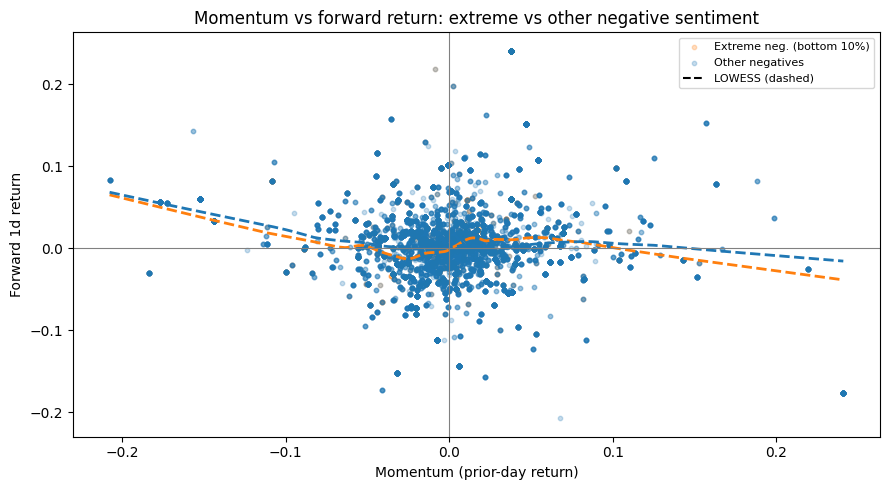

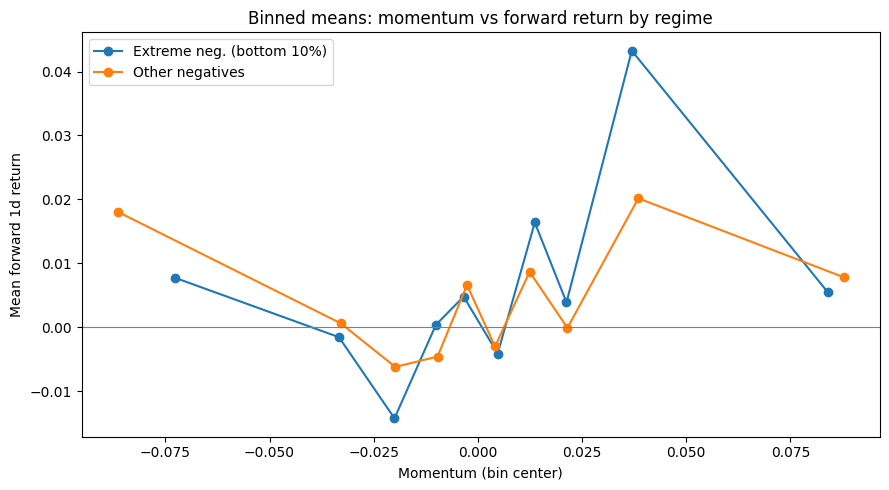

In [7]:
plot_df = fit_base.copy()
plot_df["regime"] = np.where(plot_df["neg_extreme"] == 1, "Extreme neg. (bottom 10%)", "Other negatives")

fig, ax = plt.subplots(figsize=(9, 5))
colors = {"Extreme neg. (bottom 10%)": "C1", "Other negatives": "C0"}
for regime, sub in plot_df.groupby("regime"):
    ax.scatter(
        sub["momentum_1d"],
        sub["forward_return_1d"],
        s=10,
        alpha=0.25,
        color=colors.get(regime, "C2"),
        label=regime,
    )

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess

    for regime, sub in plot_df.groupby("regime"):
        clean = sub.dropna(subset=["momentum_1d", "forward_return_1d"])
        if len(clean) < 30:
            continue
        sorted_idx = clean["momentum_1d"].argsort()
        x = clean["momentum_1d"].to_numpy()[sorted_idx]
        y = clean["forward_return_1d"].to_numpy()[sorted_idx]
        smoothed = lowess(y, x, frac=0.35, return_sorted=True)
        ax.plot(
            smoothed[:, 0],
            smoothed[:, 1],
            linewidth=2,
            color=colors.get(regime, "C2"),
            linestyle="--",
        )
    ax.plot([], [], "k--", label="LOWESS (dashed)")
except Exception as e:
    print("LOWESS skipped:", e)

ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("Momentum (prior-day return)")
ax.set_ylabel("Forward 1d return")
ax.set_title("Momentum vs forward return: extreme vs other negative sentiment")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

# Binned means for a cleaner regime comparison
bins = pd.qcut(plot_df["momentum_1d"], q=10, duplicates="drop")
plot_df["_mom_bin"] = bins
binned = (
    plot_df.groupby(["regime", "_mom_bin"], observed=True)
    .agg(
        mom_mean=("momentum_1d", "mean"),
        fwd_mean=("forward_return_1d", "mean"),
        n=("forward_return_1d", "size"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
for regime, sub in binned.groupby("regime"):
    ax.plot(sub["mom_mean"], sub["fwd_mean"], marker="o", label=regime)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Momentum (bin center)")
ax.set_ylabel("Mean forward 1d return")
ax.set_title("Binned means: momentum vs forward return by regime")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Robustness: definition of “extreme”

Refit OLS for **bottom 5% / 10% / 20%** of `sentiment_score` among negatives, plus an **absolute-score** rule (e.g. `sentiment_score <= -0.85`) when enough articles qualify—so results are not only tied to one quantile choice.

In [8]:
rows = []
for q in (0.05, 0.10, 0.20):
    fd = prepare_analysis_frame(neg_with_ret, q_bottom=q).dropna(
        subset=["forward_return_1d", "momentum_1d", "neg_extreme"]
    )
    y = fd["forward_return_1d"]
    X = sm.add_constant(fd[["momentum_1d", "neg_extreme", "momentum_x_extreme"]])
    res = sm.OLS(y, X).fit(cov_type="HC1")
    rows.append(
        {
            "spec": f"quantile q={q:.0%}",
            "n": int(res.nobs),
            "coef_mom": res.params["momentum_1d"],
            "coef_ext": res.params["neg_extreme"],
            "coef_ixn": res.params["momentum_x_extreme"],
            "p_ixn": res.pvalues["momentum_x_extreme"],
            "r2": res.rsquared,
        }
    )

for cut in (-0.85, -0.90, -0.95):
    fd_abs = prepare_analysis_frame(neg_with_ret, fixed_cutoff=cut)
    if fd_abs["neg_extreme"].sum() < 50:
        continue
    fd_abs = fd_abs.dropna(subset=["forward_return_1d", "momentum_1d", "neg_extreme"])
    y = fd_abs["forward_return_1d"]
    X = sm.add_constant(fd_abs[["momentum_1d", "neg_extreme", "momentum_x_extreme"]])
    res_a = sm.OLS(y, X).fit(cov_type="HC1")
    rows.append(
        {
            "spec": f"score <= {cut:.2f}",
            "n": int(res_a.nobs),
            "coef_mom": res_a.params["momentum_1d"],
            "coef_ext": res_a.params["neg_extreme"],
            "coef_ixn": res_a.params["momentum_x_extreme"],
            "p_ixn": res_a.pvalues["momentum_x_extreme"],
            "r2": res_a.rsquared,
        }
    )

robust_df = pd.DataFrame(rows)
print(robust_df.to_string(index=False))


          spec     n  coef_mom  coef_ext  coef_ixn    p_ixn       r2
 quantile q=5% 11007 -0.067063  0.003556  0.065648 0.236624 0.004811
quantile q=10% 11007 -0.076164  0.001154  0.164620 0.001148 0.006242
quantile q=20% 11007 -0.087689  0.000911  0.150283 0.000011 0.007478
score <= -0.85 11007 -0.085837  0.000428  0.054700 0.047878 0.005168
score <= -0.90 11007 -0.094810  0.001801  0.123171 0.000042 0.007611
score <= -0.95 11007 -0.071553  0.002079  0.145482 0.003864 0.005469


## 5. Temporal stability

Split the sample by **median article price_date** and by **calendar year** of `price_date`. Compare interaction coefficient sign/magnitude (and p-value where available).

In [9]:
def ols_coef_table(fit_df: pd.DataFrame) -> pd.Series:
    y = fit_df["forward_return_1d"]
    X = sm.add_constant(fit_df[["momentum_1d", "neg_extreme", "momentum_x_extreme"]])
    res = sm.OLS(y, X).fit(cov_type="HC1")
    return pd.Series(
        {
            "n": int(res.nobs),
            "mom": res.params["momentum_1d"],
            "ext": res.params["neg_extreme"],
            "ixn": res.params["momentum_x_extreme"],
            "p_ixn": res.pvalues["momentum_x_extreme"],
            "r2": res.rsquared,
        }
    )


fd = prepare_analysis_frame(neg_with_ret, q_bottom=0.10).dropna(
    subset=["forward_return_1d", "momentum_1d", "neg_extreme", "price_date"]
)

median_d = fd["price_date"].median()
parts = [
    ("early (price_date < median)", fd[fd["price_date"] < median_d]),
    ("late (price_date >= median)", fd[fd["price_date"] >= median_d]),
]
stab_rows = [{"split": name, **ols_coef_table(sub)} for name, sub in parts]

for yr, sub in fd.groupby(fd["price_date"].dt.year):
    sub = sub.dropna(subset=["forward_return_1d", "momentum_1d", "neg_extreme"])
    if len(sub) < 200:
        continue
    stab_rows.append({"split": f"year {yr}", **ols_coef_table(sub)})

stab_df = pd.DataFrame(stab_rows)
print(stab_df.to_string(index=False))


                      split      n       mom       ext       ixn    p_ixn       r2
early (price_date < median) 5492.0 -0.089482  0.002286  0.260971 0.011029 0.008101
late (price_date >= median) 5515.0 -0.059367 -0.000147  0.084079 0.093284 0.004338
                  year 2024 4713.0 -0.090942  0.001660  0.307625 0.009457 0.009406
                  year 2025 4624.0 -0.072427  0.004269  0.097962 0.099619 0.006600
                  year 2026 1670.0 -0.042992  0.000039 -0.077690 0.221819 0.005242


## Conclusion

### Key Takeaways

- **Extreme definition:** Bottom 10% of `sentiment_score` among negative-labeled MAG7 articles.

- **Momentum effect (OLS):** Prior-day return (`momentum_1d`) is **negatively associated** with next-day return in this sample.  
  - Coefficient $\tiny\approx$ −0.076 (p < 0.001)  
  - Higher prior returns yields lower next-day returns on average  

- **Sentiment (level effect):**
  - `neg_extreme` is **not statistically significant** (p $\tiny\approx$ 0.44)  
  - Limited evidence that extreme sentiment independently shifts returns  

- **Interaction (momentum × sentiment):**
  - Significant and positive ($\tiny\approx$ +0.105, p < 0.001)  
  - Extreme negative sentiment **modifies the momentum-return relationship**  
  - The negative slope of momentum is **less severe under extreme sentiment**  
  - Interpreted as a **conditional slope shift**, not a universal reversal  

- **Downside probability (logit):**
  - `neg_extreme` alone is not significant (p $\tiny\approx$ 0.33)  
  - Interaction is significant  $\small\rightarrow$ downside risk depends on **joint behavior with momentum**  
  - ROC-AUC $\tiny\approx$ 0.54 $\small\rarr$ modest predictive power  

---

### Effect Size & Direction

| Component                  | Direction / Magnitude        | Interpretation                                   |
|--------------------------|------------------------------|--------------------------------------------------|
| `momentum_1d` (OLS)       | Negative, significant         | Dominant linear driver in this sample             |
| `neg_extreme` (OLS)       | ~0, not significant           | Weak standalone “level” effect                    |
| `momentum × neg_extreme`  | Positive, significant         | Moderates momentum slope under extreme sentiment  |
| Logit interaction         | Significant                   | Joint effect on downside probability              |

---

### Stability & Robustness

- Interaction remains significant for alternative “extreme” thresholds (q = 10%, 20%) among negative articles  
- Not significant at tighter tails (q = 5%) → **definition-sensitive effect**  
- Temporal variation observed:
  - Significant in early sample periods and 2024  
  - Borderline in late 2025 (p ≈ 0.09–0.10)  
  - Not significant in 2026 (p ≈ 0.22)  

**Conclusion:** Full stability over time is not established; results show **heterogeneity across definitions and periods**

---

### Answer to Hypothesis

**Partially supported, with caveats.**

Extreme negative sentiment **does not independently drive returns**, but it **modifies the relationship between momentum and next-day returns**.

- Evidence supports a **conditional (interaction-based) effect**
- No strong support for a **standalone sentiment signal**
- Results are **sample-dependent and not universally stable**

---

### Next Steps

- Treat prior-day return as the baseline signal and model extreme negative sentiment as a **multiplicative modifier** (interaction or regime-based)
- Because stability is incomplete, estimate effects using:
  - Walk-forward validation  
  - Subsample analysis  
  - Alternative extreme definitions  
- Improve inference design:
  - Cluster standard errors by `price_date` and/or `ticker`  
  - Consider marginal effects for logit interpretation  
- Validate robustness:
  - Check whether 2026 results are driven by short-sample noise  
  - Evaluate sensitivity to different sentiment thresholds and filters  